# Домашнее задание к семинару 13 (HW13)

## 1. Импорты, seed и среда

In [47]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split

In [39]:
import os

artifacts_dir = "artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Данные и первичный анализ

In [4]:
dataset = load_dataset("emotion")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
for split_name in dataset.keys():
    print(f"{split_name}: {len(dataset[split_name])}")

train: 16000
validation: 2000
test: 2000


In [6]:
label_feature = dataset["train"].features["label"]
class_names = label_feature.names

print("Классы:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Классы:
0: sadness
1: joy
2: love
3: anger
4: fear
5: surprise


In [7]:
sample_count = 5

for i in range(sample_count):
    text = dataset["train"][i]["text"]
    label_id = dataset["train"][i]["label"]
    label_name = class_names[label_id]

    print(f"Пример {i+1}")
    print("Текст:", text)
    print("Метка:", label_id, "-", label_name)
    print("")

Пример 1
Текст: i didnt feel humiliated
Метка: 0 - sadness

Пример 2
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Метка: 0 - sadness

Пример 3
Текст: im grabbing a minute to post i feel greedy wrong
Метка: 3 - anger

Пример 4
Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Метка: 2 - love

Пример 5
Текст: i am feeling grouchy
Метка: 3 - anger



Распределение классов в train

In [8]:
train_labels = [example["label"] for example in dataset["train"]]
train_label_names = [class_names[label] for label in train_labels]

pd.Series(train_label_names).value_counts()

joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

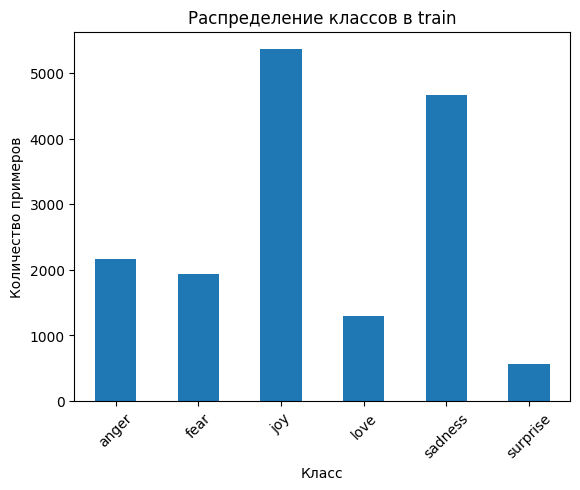

In [9]:
pd.Series(train_label_names).value_counts().sort_index().plot(kind="bar")
plt.title("Распределение классов в train")
plt.xlabel("Класс")
plt.ylabel("Количество примеров")
plt.xticks(rotation=45)
plt.show()

В данной работе рассматривается задача многоклассовой классификации текста.
Необходимо по текстовому сообщению определить, какая эмоция в нём выражена.
В датасете emotion используются 6 классов: sadness, joy, love, anger, fear, surprise.
Таким образом, модель должна по входному тексту предсказать одну из шести эмоциональных категорий.

## 3. Токенизация

Берём базовую модель

In [10]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [11]:
texts = [dataset["train"][i]["text"] for i in range(5)]

for i, text in enumerate(texts):
    print(f"Текст {i+1}: {text}")
    print("")

Текст 1: i didnt feel humiliated

Текст 2: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Текст 3: im grabbing a minute to post i feel greedy wrong

Текст 4: i am ever feeling nostalgic about the fireplace i will know that it is still on the property

Текст 5: i am feeling grouchy



Показываем токенизацию

In [12]:
encoded = tokenizer(texts, add_special_tokens=True)
for i in range(len(texts)):
    print(f"Пример {i+1}")
    
    print("Оригинальный текст:")
    print(texts[i])
    
    print("\nТокены:")
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][i])
    print(tokens)
    
    print("\ninput_ids:")
    print(encoded["input_ids"][i])
    
    print("\nattention_mask:")
    print(encoded["attention_mask"][i])
    
    print("")

Пример 1
Оригинальный текст:
i didnt feel humiliated

Токены:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']

input_ids:
[101, 1045, 2134, 2102, 2514, 26608, 102]

attention_mask:
[1, 1, 1, 1, 1, 1, 1]

Пример 2
Оригинальный текст:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Токены:
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']

input_ids:
[101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]

attention_mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 3
Оригинальный текст:
im grabbing a minute to post i feel greedy wrong

Токены:
['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]']

input_ids:
[101, 10

In [13]:
print("Special tokens:")
print("CLS token:", tokenizer.cls_token, tokenizer.cls_token_id)
print("SEP token:", tokenizer.sep_token, tokenizer.sep_token_id)
print("PAD token:", tokenizer.pad_token, tokenizer.pad_token_id)

Special tokens:
CLS token: [CLS] 101
SEP token: [SEP] 102
PAD token: [PAD] 0


Пример padding

In [14]:
encoded_padded = tokenizer(
    texts,
    padding=True,
    truncation=False,
    return_tensors=None
)

for i in range(len(texts)):
    print(f"Пример {i+1} (с padding)")
    print("input_ids:", encoded_padded["input_ids"][i])
    print("attention_mask:", encoded_padded["attention_mask"][i])
    print("")

Пример 1 (с padding)
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Пример 2 (с padding)
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 3 (с padding)
input_ids: [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505, 3308, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Пример 4 (с padding)
input_ids: [101, 1045, 2572, 2412, 3110, 16839, 9080, 12863, 2055, 1996, 13788, 1045, 2097, 2113, 2008, 2009, 2003, 2145, 2006, 1996, 3200, 102, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]

Пример 5 (с padding)
input_ids: [101, 1045, 2572, 3

Пример truncation

In [15]:
encoded_truncated = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=10
)

for i in range(len(texts)):
    print(f"Пример {i+1} (с truncation)")
    print("input_ids:", encoded_truncated["input_ids"][i])
    print("attention_mask:", encoded_truncated["attention_mask"][i])
    print("")

Пример 1 (с truncation)
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]

Пример 2 (с truncation)
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 3 (с truncation)
input_ids: [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 4 (с truncation)
input_ids: [101, 1045, 2572, 2412, 3110, 16839, 9080, 12863, 2055, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 5 (с truncation)
input_ids: [101, 1045, 2572, 3110, 24665, 7140, 11714, 102, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]



Токенизация преобразует текст в числовое представление, понятное модели.
В процессе:

	1) текст разбивается на токены;
	2) токены переводятся в input_ids;
	3) формируется attention_mask;
	4) добавляются специальные токены ([CLS], [SEP]);
	5) применяется padding для выравнивания длины и truncation для ограничения размера входа.

Таким образом, текст подготавливается к подаче в нейронную модель.

## 4. Инференс готовой модели

In [16]:
from transformers import pipeline

clf = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 67733.30it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
sample_texts = [dataset["test"][i]["text"] for i in range(5)]
sample_labels = [dataset["test"][i]["label"] for i in range(5)]

for i in range(len(sample_texts)):
    print(f"Пример {i+1}")
    print("Текст:", sample_texts[i])
    print("Истинная метка:", class_names[sample_labels[i]])
    print("")

Пример 1
Текст: im feeling rather rotten so im not very ambitious right now
Истинная метка: sadness

Пример 2
Текст: im updating my blog because i feel shitty
Истинная метка: sadness

Пример 3
Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Истинная метка: sadness

Пример 4
Текст: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
Истинная метка: joy

Пример 5
Текст: i was feeling a little vain when i did this one
Истинная метка: sadness



In [18]:
predictions = clf(sample_texts)
print(predictions[0])

for i, preds in enumerate(predictions):
    print(f"Пример {i+1}")
    print("Текст:", sample_texts[i])
    print("Истинная метка:", class_names[sample_labels[i]])

    sorted_preds = sorted(preds, key=lambda x: x["score"], reverse=True)

    print("Топ-3 предсказания:")
    for p in sorted_preds[:3]:
        print(f"  {p['label']}: {p['score']:.4f}")

    print("")

[{'label': 'sadness', 'score': 0.9915076494216919}, {'label': 'anger', 'score': 0.0030184227507561445}, {'label': 'joy', 'score': 0.0026901152450591326}, {'label': 'surprise', 'score': 0.0008147931075654924}, {'label': 'disgust', 'score': 0.0007758710999041796}, {'label': 'fear', 'score': 0.0007279975106939673}, {'label': 'neutral', 'score': 0.00046505406498908997}]
Пример 1
Текст: im feeling rather rotten so im not very ambitious right now
Истинная метка: sadness
Топ-3 предсказания:
  sadness: 0.9915
  anger: 0.0030
  joy: 0.0027

Пример 2
Текст: im updating my blog because i feel shitty
Истинная метка: sadness
Топ-3 предсказания:
  sadness: 0.9933
  anger: 0.0015
  disgust: 0.0014

Пример 3
Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Истинная метка: sadness
Топ-3 предсказания:
  sadness: 0.9825
  neutral: 0.0054
  disgust: 0.0048

Пример 4
Текст: i left with my bouquet of red and yellow tulips under my arm feeling slightly 

## 5. Fine-tuning для классификации текста

In [19]:
import numpy as np
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

In [20]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = len(class_names)
print("Число классов:", num_labels)
print("Классы:", class_names)

Число классов: 6
Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [21]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

In [22]:
tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [23]:
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [24]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [25]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

model.to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9018.84it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [26]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy": accuracy["accuracy"],
        "f1_macro": f1["f1"]
    }

In [27]:
training_args = TrainingArguments(
    output_dir="./results_hw13",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    report_to="none",
    seed=SEED
)

In [29]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
trainer.train()

/opt/homebrew/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.505324,0.192001,0.930500,0.904112
2,0.148703,0.151712,0.942000,0.920848


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.09it/s]
/opt/homebrew/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.72it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2000, training_loss=0.32701357269287107, metrics={'train_runtime': 448.5664, 'train_samples_per_second': 71.338, 'train_steps_per_second': 4.459, 'total_flos': 389287358125632.0, 'train_loss': 0.32701357269287107, 'epoch': 2.0})

In [30]:
print("Лучший checkpoint:", trainer.state.best_model_checkpoint)
print("Лучшая метрика на validation:", trainer.state.best_metric)

Лучший checkpoint: ./results_hw13/checkpoint-2000
Лучшая метрика на validation: 0.9208476060531995


In [33]:
from sklearn.metrics import accuracy_score, f1_score

test_output = trainer.predict(tokenized_dataset["test"])

test_logits = test_output.predictions
test_true = test_output.label_ids
test_pred = np.argmax(test_logits, axis=-1)

test_metrics = {
    "test_accuracy": accuracy_score(test_true, test_pred),
    "test_f1_macro": f1_score(test_true, test_pred, average="macro")
}

print(test_metrics)

/opt/homebrew/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'test_accuracy': 0.924, 'test_f1_macro': 0.8842161449988922}


In [34]:
print("Результаты на test:")
for key, value in test_metrics.items():
    print(f"{key}: {value}")

Результаты на test:
test_accuracy: 0.924
test_f1_macro: 0.8842161449988922


## 6. Оценка качества и краткий анализ ошибок



In [35]:
predictions = trainer.predict(tokenized_dataset["test"])
logits = predictions.predictions
true_labels = predictions.label_ids

pred_labels = np.argmax(logits, axis=-1)

/opt/homebrew/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [37]:
accuracy = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average="macro")

print("Accuracy:", round(accuracy, 4))
print("F1 macro:", round(f1, 4))

Accuracy: 0.924
F1 macro: 0.8842


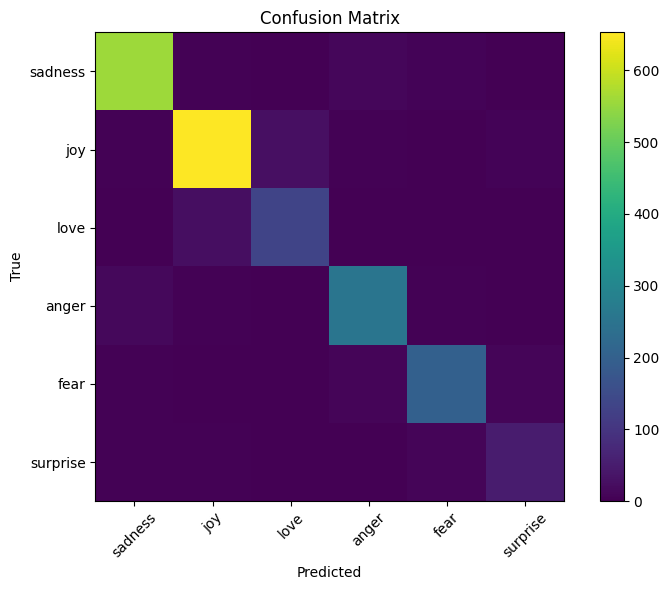

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45)
plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig(f"{artifacts_dir}/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
plt.show()

In [41]:
test_texts = dataset["test"]["text"]

for i in range(10):
    print(f"Пример {i+1}")
    print("Текст:", test_texts[i])
    print("Истинная метка:", class_names[true_labels[i]])
    print("Предсказание:", class_names[pred_labels[i]])   
    if true_labels[i] != pred_labels[i]:
        print("Error!")
    else:
        print("Ok!")
    
    print("")

Пример 1
Текст: im feeling rather rotten so im not very ambitious right now
Истинная метка: sadness
Предсказание: sadness
Ok!

Пример 2
Текст: im updating my blog because i feel shitty
Истинная метка: sadness
Предсказание: sadness
Ok!

Пример 3
Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Истинная метка: sadness
Предсказание: sadness
Ok!

Пример 4
Текст: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
Истинная метка: joy
Предсказание: joy
Ok!

Пример 5
Текст: i was feeling a little vain when i did this one
Истинная метка: sadness
Предсказание: sadness
Ok!

Пример 6
Текст: i cant walk into a shop anywhere where i do not feel uncomfortable
Истинная метка: fear
Предсказание: fear
Ok!

Пример 7
Текст: i felt anger when at the end of a telephone call
Истинная метка: anger
Предсказание: anger
Ok!

Пример 8
Текст: i explain why i clung to a relationship with a boy who 

In [42]:
errors = []
for i in range(len(test_texts)):
    if true_labels[i] != pred_labels[i]:
        errors.append(i)
print("Количество ошибок:", len(errors))

Количество ошибок: 152


In [43]:
for i in errors[:5]:
    print("Текст:", test_texts[i])
    print("Истинная:", class_names[true_labels[i]])
    print("Предсказание:", class_names[pred_labels[i]])
    print("")

Текст: i don t feel particularly agitated
Истинная: fear
Предсказание: anger

Текст: i feel a bit stressed even though all the things i have going on are fun
Истинная: anger
Предсказание: sadness

Текст: i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love
Истинная: joy
Предсказание: love

Текст: when a friend dropped a frog down my neck
Истинная: anger
Предсказание: fear

Текст: i feel agitated with myself that i did not foresee her frustrations earlier leading to the ending of our relationship
Истинная: fear
Предсказание: anger



В результате обучения модели distilbert-base-uncased для задачи классификации эмоций были получены следующие метрики качества:

	Accuracy: 0.924
	F1 macro: 0.8842`

Полученные значения свидетельствуют о том, что модель в целом успешно решает задачу многоклассовой классификации текста.

Анализ матрицы ошибок показывает, что наибольшее количество ошибок возникает между классами, имеющими схожую эмоциональную окраску, например:

	anger и fear;
	joy и love.

Это объясняется тем, что границы между данными классами являются размытыми и зависят от контекста.

In [44]:
import pandas as pd
import numpy as np

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
confidences = probs.max(axis=1)

n_examples = 10

sample_df = pd.DataFrame({
    "text": test_texts[:n_examples],
    "true_label": [class_names[i] for i in true_labels[:n_examples]],
    "pred_label": [class_names[i] for i in pred_labels[:n_examples]],
    "confidence": confidences[:n_examples]
})

sample_df.to_csv(f"{artifacts_dir}/sample_predictions.csv", index=False, encoding="utf-8")
sample_df

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.997138
1,im updating my blog because i feel shitty,sadness,sadness,0.997445
2,i never make her separate from me because i do...,sadness,sadness,0.997355
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.997383
4,i was feeling a little vain when i did this one,sadness,sadness,0.997371
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.993648
6,i felt anger when at the end of a telephone call,anger,anger,0.994591
7,i explain why i clung to a relationship with a...,joy,joy,0.828391
8,i like to have the same breathless feeling as ...,joy,joy,0.996224
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.995864


## Выводы

В рамках домашней работы был проведён один основной эксперимент fine-tuning модели для задачи классификации текста.

Параметры эксперимента:

	датасет: emotion;
	модель: distilbert-base-uncased;
	разбиение данных: готовые части train, validation, test;
	задача: многоклассовая классификация эмоций по тексту.

В ходе эксперимента модель обучалась на обучающей выборке train. Выбор лучшего варианта осуществлялся по качеству на выборке validation. После завершения обучения лучшая версия модели была один раз оценена на тестовой выборке test.

Такой подход обеспечивает корректную организацию эксперимента: тестовая выборка не использовалась при подборе модели и гиперпараметров, а итоговая оценка была выполнена только после завершения этапа выбора лучшего варианта.